# LG-SSM

In [6]:
import numpy as np
from scipy.linalg import expm

b = 0.5  # friction coefficient
m = 1.0  # robot mass
k = 0.2  # spring constant (elastic coupling)
A = np.array([[0, -1], [k / m, -b / m]])
B = np.array([[0, 1], [1 / m, 0]])
C = np.array([[1, 0]])
D = np.array([[0, 0]])

dt = 1.0
A_d = expm(A * dt)
B_d = np.linalg.solve(A, (A_d - np.eye(A.shape[0])) @ B)

print("A_d =\n", A_d)
print("B_d =\n", B_d)

A_d =
 [[ 0.91613782 -0.76107557]
 [ 0.15221511  0.53560004]]
B_d =
 [[-0.41931088  0.97073101]
 [ 0.76107557  0.08386218]]


In [7]:
from scipy import signal

dt = 1.0
sys_c = signal.StateSpace(A, B, C, D)
sys_d = sys_c.to_discrete(dt, method='zoh')
A_d, B_d, C_d, D_d = sys_d.A, sys_d.B, sys_d.C, sys_d.D

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal
from typing import Tuple

def generate_robot_data(
    t, u, b=0.5, m=1.0, k=0.2, noise_std=0.05
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Generate synthetic data for the mobile companion robot interaction.
    `t` is a time vector and `u` is a 2D input array (robot force, user velocity).
    """
    assert t is not None, "Time vector t must be provided"
    assert u.shape[0] == t.shape[0], (
        "Input signal u must have the same number of time steps as t"
    )

    # Mobile companion robot dynamics in state space representation
    A = np.array([[0, -1], [k / m, -b / m]])
    B = np.array([[0, 1], [1 / m, 0]])
    C = np.eye(2)
    D = np.zeros((2, 2))

    sys = signal.StateSpace(A, B, C, D)

    # Simulate the system and add some noise
    t_out, y_clean, x = signal.lsim(sys, u, t)
    noise = np.random.normal(0, noise_std, y_clean.shape)
    y_noisy = y_clean + noise

    return x, y_noisy, y_clean

def generate_input(t) -> np.ndarray:
    """
    Generate input signals: robot force and user velocity disturbances.
    """
    u = np.zeros((len(t), 2))

    # Robot force: random pulses
    i = 0
    delta = 10
    while i < len(t) - delta:
        val = np.random.choice([-1, 0, 1])
        u[i : i + delta, 0] = val
        i += delta

    # User velocity: random walk pattern
    i = 0
    while i < len(t) - delta:
        val = np.random.choice([-0.5, 0, 0.5])
        u[i : i + delta, 1] = val
        i += delta

    # Add some random noise to inputs
    u += np.random.normal(0, 0.01, size=u.shape)

    return u

In [9]:
np.random.seed(42)
N = 100
ts = np.linspace(0, N, N + 1)
us = generate_input(ts)
xs, ys, y_clean = generate_robot_data(ts, us)

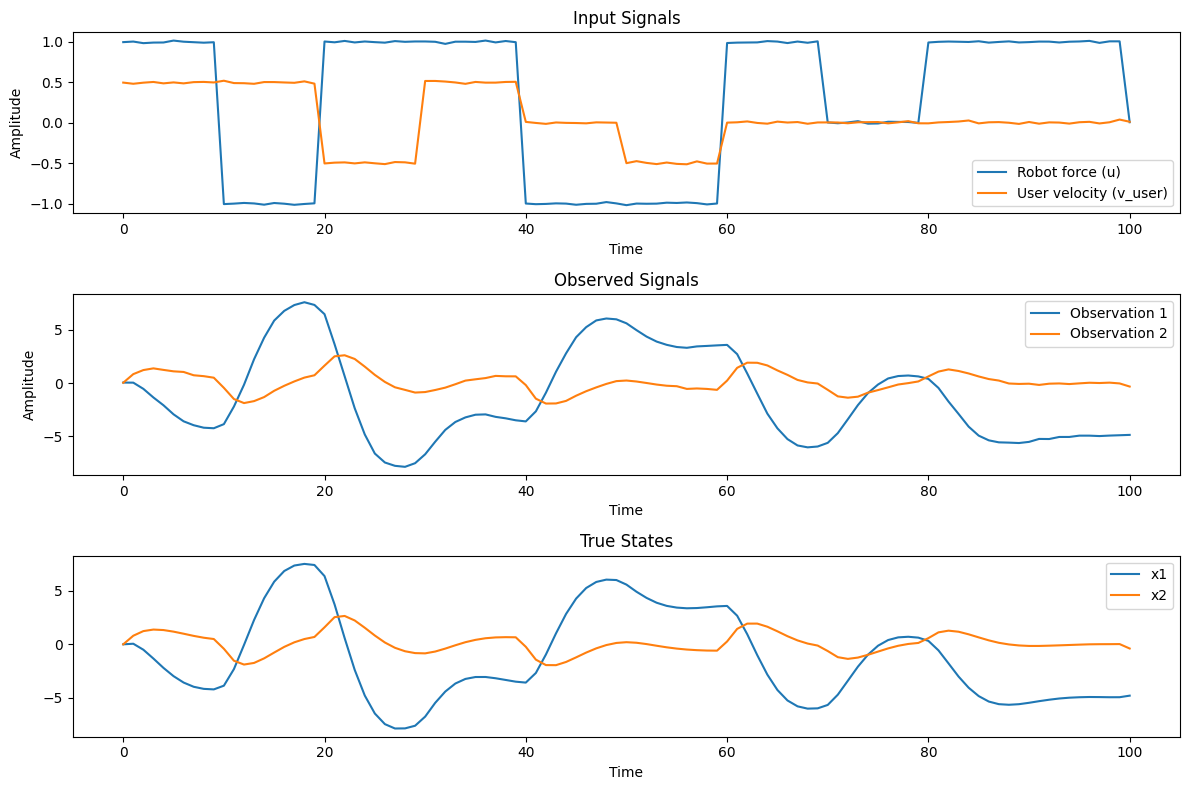

In [10]:
def plot_signals(
    ts: np.ndarray, us: np.ndarray, ys: np.ndarray, xs: np.ndarray
) -> None:
    """Plot the datasets"""
    fig = plt.figure(figsize=(12, 8))

    # Plot input signals
    plt.subplot(3, 1, 1)
    plt.plot(ts, us[:, 0], label="Robot force (u)")
    plt.plot(ts, us[:, 1], label="User velocity (v_user)")
    plt.title("Input Signals")
    plt.xlabel("Time")
    plt.ylabel("Amplitude")
    plt.legend()

    # Plot output signals
    seq_len, obs_dim = ys.shape
    assert obs_dim == 2, "Output signal must have 2 dimensions"
    plt.subplot(3, 1, 2)
    for i in range(obs_dim):
        plt.plot(ts, ys[:, i], label=f"Observation {i + 1}")
    plt.title("Observed Signals")
    plt.xlabel("Time")
    plt.ylabel("Amplitude")
    plt.legend()

    # Plot true states
    seq_len, state_dim = xs.shape
    plt.subplot(3, 1, 3)
    for i in range(state_dim):
        plt.plot(ts, xs[:,i], label=f"State {i + 1}")
    plt.title("True States")
    plt.legend(["x1", "x2"])
    plt.xlabel("Time")

    plt.tight_layout()

    # Show all figures
    plt.show()

plot_signals(ts, us, ys, xs)


In [11]:
import arviz as az
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
import numpyro.distributions.constraints as constraints
import os
import pandas as pd
import seaborn as sns
from jax import lax, random
from numpyro.contrib.control_flow import scan
from numpyro.diagnostics import hpdi
from numpyro.infer import MCMC, NUTS, Predictive
from numpyro.infer.util import initialize_model
from numpyro.primitives import plate

numpyro.set_platform("cpu")
numpyro.set_host_device_count(1)

def lgssm(ts, U, X, Y):
    num_time_steps, input_dim = U.shape
    num_input_time_steps, state_dim = X.shape
    num_obs_time_steps, obs_dim = Y.shape
    assert num_time_steps == num_input_time_steps, "Time steps must match"
    assert num_time_steps == num_obs_time_steps, "Time steps must match"

    # Parameters for the state space model
    b = numpyro.sample("b", dist.Gamma(1.0, 1.0,))
    m = numpyro.sample("m", dist.Gamma(1.0, 1.0,))
    k = numpyro.sample("k", dist.Gamma(1.0, 1.0,))

    A = jnp.array([[0, -1], [k / m, -b / m]])
    B = jnp.array([[0, 1], [1 / m, 0]])
    C = jnp.eye(2)

    # Exact discretization via matrix exponential (zero-order hold)
    dt = ts[1] - ts[0]
    A_d = jax.scipy.linalg.expm(A * dt)
    B_d = jnp.linalg.solve(A, (A_d - jnp.eye(state_dim)) @ B)

    # For each state, set the initial state and define noise
    with plate("state_dim", state_dim):
        x0 = numpyro.sample("x0", dist.Normal(0, 1))
        qs = numpyro.sample("Q", dist.HalfNormal(1.0))

    with plate("obs_dim", obs_dim):
        rs = numpyro.sample("R", dist.HalfNormal(1.0))

    Q = jnp.diag(qs)
    R = jnp.diag(rs)

    # Define the transition function for scanning
    def transition_fn(x_prev, t):
        x = jnp.dot(A_d, x_prev) + jnp.dot(B_d, U[t]).squeeze()
        x_t = numpyro.sample(f"x_{t}", dist.MultivariateNormal(x, Q))

        y = jnp.dot(C, x_t)
        numpyro.sample(f"y_{t}", dist.MultivariateNormal(y, R), obs=Y[t])
        return x_t, None

    _, _ = scan(transition_fn, x0, jnp.arange(1, num_time_steps))

    return

# Format the data
T = jnp.array(ts)
U = jnp.array(us)
X = jnp.array(xs)
Y = jnp.array(ys)

print(U.shape)
print(X.shape)
print(Y.shape)

(101, 2)
(101, 2)
(101, 2)


In [ ]:
from numpyro.infer import SVI, Trace_ELBO
from numpyro.infer.autoguide import AutoNormal

guide = AutoNormal(lgssm)
optimizer = numpyro.optim.Adam(0.005)
svi = SVI(lgssm, guide, optimizer, loss=Trace_ELBO())

rng_key = random.PRNGKey(0)
svi_result = svi.run(
    rng_key, 10000, ts=T, U=U, X=X, Y=Y, progress_bar=True
)

# Extract point estimates (posterior medians)
params = svi_result.params
median_params = guide.median(params)
print(f"b: {median_params['b']:.4f} (true: 0.5)")
print(f"m: {median_params['m']:.4f} (true: 1.0)")
print(f"k: {median_params['k']:.4f} (true: 0.2)")
# b: 0.5346 (true: 0.5)
# m: 1.3654 (true: 1.0)
# k: 0.2045 (true: 0.2)

100%|██████████| 10000/10000 [00:06<00:00, 1659.50it/s, init loss: 5898.0439, avg. loss [9501-10000]: -74.3900]


b: 0.5346 (true: 0.5)
m: 1.3654 (true: 1.0)
k: 0.2045 (true: 0.2)
